In [130]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
df=pd.read_csv('archive/train.csv')

In [131]:
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [135]:
# Checking Accuracy Before Feature Engineering

In [133]:
X_train=df.drop(columns='Activity')

In [134]:
y_train=df['Activity']

In [136]:
df_test=pd.read_csv('archive/test.csv')

In [137]:
X_test=df_test.drop(columns='Activity')

In [138]:
y_test=df_test['Activity']

In [139]:
# Initialize and train logistic regression model
log_reg = LogisticRegression(max_iter=1000)  # Increase max_iter if it doesn't converge
log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg.predict(X_test)

# Calculate and print accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", accuracy)

Test accuracy: 0.9599592806243638


In [140]:
columns=X_train.columns.values
duplicate=[]

In [141]:
# Duplciate Removal Technique

In [142]:
for i in range(columns.shape[0]):
    for j in range(i+1,columns.shape[0]-1):
        if((X_train[columns[i]].values==X_train[columns[j]].values).all()):
            duplicate.append(columns[j])

In [143]:
columns=list(columns)
columns=pd.Series(columns)

In [144]:
columns.shape

(562,)

In [145]:
len(duplicate)

24

In [146]:
duplicate=list(set(duplicate))
len(duplicate)

21

In [147]:
duplicate

['tGravityAccMag-max()',
 'fBodyAccMag-sma()',
 'tGravityAccMag-entropy()',
 'tGravityAccMag-arCoeff()2',
 'fBodyBodyGyroMag-sma()',
 'tBodyGyroMag-sma()',
 'tBodyAccMag-sma()',
 'fBodyBodyAccJerkMag-sma()',
 'tGravityAccMag-mean()',
 'fBodyBodyGyroJerkMag-sma()',
 'tBodyGyroJerkMag-sma()',
 'tGravityAccMag-mad()',
 'tGravityAccMag-sma()',
 'tGravityAccMag-iqr()',
 'tGravityAccMag-arCoeff()1',
 'tGravityAccMag-std()',
 'tGravityAccMag-energy()',
 'tGravityAccMag-arCoeff()4',
 'tBodyAccJerkMag-sma()',
 'tGravityAccMag-arCoeff()3',
 'tGravityAccMag-min()']

In [148]:
df_tech1=X_train.drop(columns=duplicate)

In [149]:
# Result of Remove Duplicate 562->541

In [150]:
df_tech1.shape

(7352, 541)

In [151]:
X_train=df_tech1

In [152]:
#  Constant Removal Variance Threshold Technique

In [153]:
from sklearn.feature_selection import VarianceThreshold
sel=VarianceThreshold(threshold=0.05)

In [154]:
sel.fit(X_train)

,threshold,0.05


In [155]:
sum(sel.get_support())

np.int64(350)

In [156]:
columns=X_train.columns[sel.get_support()]

In [157]:
df_tech_12=X_train[columns]

In [160]:
df_tech_12.shape

(7352, 350)

In [161]:
X_train=df_tech_12

In [162]:
# Result of Variance Threshold 541->350

In [163]:
# Correlation Technique

In [164]:
import seaborn as sns

<Axes: >

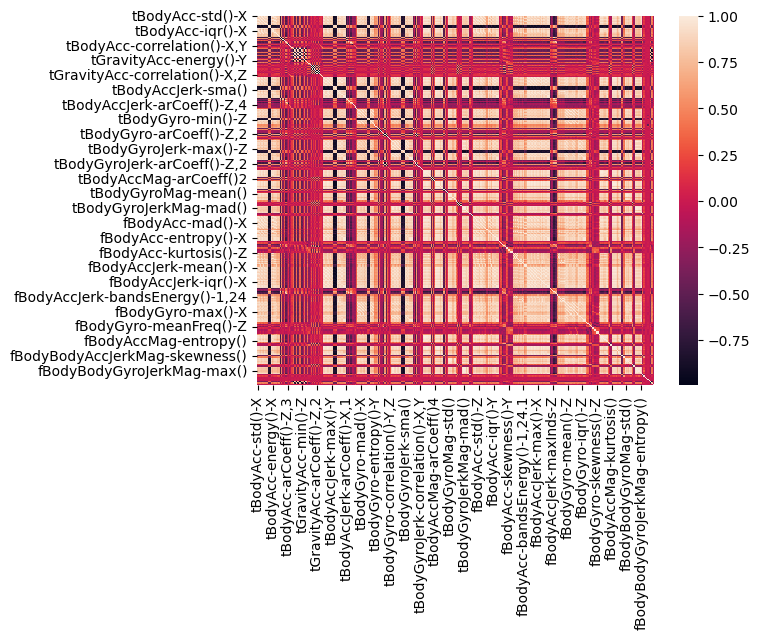

In [165]:
sns.heatmap(X_train.corr())

In [166]:
corr_matrix=X_train.corr()
columns = corr_matrix.columns
drop_columns=[]
X_train.shape[1]
for i in range(X_train.shape[1]):
    for j in range(i+1,X_train.shape[1]):
        if corr_matrix.loc[columns[i], columns[j]] > 0.95:
            drop_columns.append(columns[j])
len(set(drop_columns))

197

In [167]:
df_tech_123=X_train.drop(columns=drop_columns)

In [168]:
X_train=df_tech_123

In [169]:
df_tech_123.shape

(7352, 153)

In [170]:
# Result of Removing highly correalted columns 350->153

In [171]:
# ANOVA Technique

In [172]:
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest

sel=SelectKBest(f_classif,k=100).fit(X_train,y_train)
columns=X_train.columns[sel.get_support()]

In [173]:
df_tech_1234=X_train[X_train.columns[sel.get_support()]]

In [174]:
X_train=df_tech_1234

In [177]:
df_tech_1234.shape

(7352, 100)

In [178]:
# Result of using ANOVA to select best 100 columns 153->100